In [1]:
import jinns
import jax
from jax import random, vmap
import jax.numpy as jnp
import equinox as eqx
import numpy as np
import matplotlib.pyplot as plt
from   jinns.data import append_obs_batch
import optax
from jinns.loss._DynamicLossAbstract import ODE
from jinns.parameters import Params
from jaxtyping import Array, Float

key = random.PRNGKey(2)
key, subkey = random.split(key)

In [2]:
gluc_data = np.hsplit(np.loadtxt("./data/glucose.dat"), [1])
data_t = gluc_data[0]
data_y = gluc_data[1]

## 1. Create the datagenerators objects

In [3]:
# ODE time points sampling preparation
nt = int(2**12)    # total number of collocation points that will be drawn across [tmin, tmax]
batch_size = 256   # how many time points will be drawn at each training iteration
method = "uniform" # sampling is uniform in time
tmin = 0
tmax = 1800

Tmax = 1
key, subkey = random.split(key)
train_data = jinns.data.DataGeneratorODE( # producing batches of collocation points in the time domain where the PINN will enforce the ODE residuals
    key=subkey,
    nt=nt,
    tmin=tmin,
    tmax=tmax,
    temporal_batch_size=batch_size,
    method=method,
)

In [4]:
# Experimental time points sampling preparation
n = 1800 # dataset length
key, subkey = random.split(key)
idx = jnp.append( # selecting indices of observed data points from loaded dataset data_t and data_y --> time points from the experimental dataset
    jax.random.choice(subkey, jnp.arange(1, n - 1), shape=(n // 5,), replace=False), # 360 random indices from the middle
    jnp.array([0, n - 1]),
)

In [5]:
# Uniformized experimental observations sampling preparation

key, subkey = random.split(key) 
obs_batch_size = 256  # must be equal to time_batch_size
obs_data = jinns.data.DataGeneratorObservations(  # preparing the supervised (i.e. measures) part of training data
    obs_batch_size=obs_batch_size,
    observed_pinn_in=data_t[idx].squeeze() / Tmax, # the input times of your observations, scaled by Tmax (so here, normalized time in [0,1])
    observed_values=data_y[idx, 2], # the corresponding observed values
    key=subkey,
)

## 2. Create the neural networks

The following cells create 6 neural networks for the 6 outputs we are trying to predict.

**Important**: both the input (feature) <python>t</python> and the ouput of the network change in this example. To do this, we use the <python>input_transform</python> and output_transform functionnalities of the PINN creation. Below we define the transformation as described in the original work we are trying to reproduce.

In [6]:
eqx_list = (
    (eqx.nn.Linear, 6, 40),  
    (jax.nn.tanh,),
    (eqx.nn.Linear, 40, 40), 
    (jax.nn.tanh,),
    (eqx.nn.Linear, 40, 40), 
    (jax.nn.tanh,),
    (eqx.nn.Linear, 40, 40), 
    (jax.nn.tanh,),
    (eqx.nn.Linear, 40, 40), 
    (jax.nn.tanh,),
    (eqx.nn.Linear, 40, 6),  
)

In [7]:
def feature_transform(t, params):
    """
    NOTE: t and params are mandatory parameters for an `input_transform`
    function in jinns.

    Here, the params are not used, but it could.
    """
    t = 0.01 * t
    # Takes scalar time t and maps it to a 6-vector: [t, sin(t), sin(2t), …, sin(5t)]
    # The 0.01 scaling keeps arguments to sin in a gentle range (helps optimization) -> classical normalization

    return jnp.concatenate(
        [t, jnp.sin(t), jnp.sin(2 * t), jnp.sin(3 * t), jnp.sin(4 * t), jnp.sin(5 * t)],
        axis=0,
    )

In [8]:
def output_transform(t, y, params):
    idx = 1799
    t = t.squeeze() * 1
    # Build a straight line through (t0, y0) and (t_idx, y_idx) for each of the 6 variables
    k = (data_y[idx, :] - data_y[0, :]) / (data_t[idx] - data_t[0])
    b = (data_t[idx] * data_y[0, :] - data_t[0] * data_y[idx, :]) / (
        data_t[idx] - data_t[0]
    )
    linear = k.squeeze() * t + b.squeeze()
    # Window that is ~0 near the edges and ~1 in the interior
    factor = jnp.tanh(t) * jnp.tanh(idx - t)

    # Final output = linear trend + windowed NN correction (with a per-variable scale)
    return linear + factor * jnp.array([1, 1, 1e2, 1, 1, 1]) * y

In [9]:
## Build the PINN model (u) and the initial NN parameters (init_nn_params)
u, init_nn_params = jinns.nn.PINN_MLP.create(
    key=subkey,
    eqx_list=eqx_list,
    eq_type="ODE",
    input_transform=feature_transform,
    output_transform=output_transform,
)

## 3. Create the two dictionnaries of nn_params and eq_params used in the system

In [10]:
# map an unconstrained scalar to a bounded, positive range
def get_variable(v, var):
    # defined by the authors of the original work
    low, up = v * 0.2, v * 1.8       # 20%–180% of a nominal value v
    l = (up - low) / 2               # = 0.8*v
    v1 = l * jnp.tanh(var) + l + low # maps (-inf,inf) → (low, up), centered at v
    return v1

In [11]:
# "Guessed" seeds
E_ = 0.0
tp_ = 0.0
ti_ = 0.0
td_ = 0.0
k_ = 0.0
Rm_ = 0.0
a1_ = 0.0
C1_ = 0.0
C2_ = 0.0
C4_ = 0.0
C5_ = 0.0
Ub_ = 0.0
U0_ = 0.0
Um_ = 0.0
Rg_ = 0.0
alpha_ = 0.0
beta_ = 0.0

In [12]:
# This is the actual data we have for some equation parameters
meal_data = jnp.hsplit(np.loadtxt("./data/meal.dat"), [4])
meal_t = meal_data[0].astype(float) / Tmax
meal_q = meal_data[1].astype(float)

In [13]:
init_params = jinns.parameters.Params(
    nn_params=init_nn_params, 
    eq_params={
        "Vp": 3.0,                                   # constant
        "Vi": 11.0,                                  # constant
        "Vg": 10.0,                                  # constant
        "E": (jnp.tanh(E_) + 1) * 0.1 + 0.1,         # trainable: fixed bounds
        "tp": (jnp.tanh(tp_) + 1) * 2 + 4,           # trainable: fixed bounds
        "ti": (jnp.tanh(ti_) + 1) * 40 + 60,         # trainable: fixed bounds
        "td": (jnp.tanh(td_) + 1) * 25 / 6 + 25 / 3, # trainable: fixed bounds
        "k": get_variable(0.0083, k_),               # trainable: nominal bounds (±80%)
        "Rm": get_variable(209 / 100, Rm_),          # trainable: nominal bounds (±80%)
        "a1": get_variable(6.6, a1_),                # trainable: nominal bounds (±80%)
        "C1": get_variable(300 / 100, C1_),          # trainable: nominal bounds (±80%)
        "C2": get_variable(144 / 100, C2_),          # trainable: nominal bounds (±80%)
        "C3": 100 / 100,                             # constant
        "C4": get_variable(80 / 100, C4_),           # trainable: nominal bounds (±80%)
        "C5": get_variable(26 / 100, C5_),           # trainable: nominal bounds (±80%)
        "Ub": get_variable(72 / 100, Ub_),           # trainable: nominal bounds (±80%)
        "U0": get_variable(4 / 100, U0_),            # trainable: nominal bounds (±80%)
        "Um": get_variable(90 / 100, Um_),           # trainable: nominal bounds (±80%)
        "Rg": get_variable(180 / 100, Rg_),          # trainable: nominal bounds (±80%)
        "alpha": get_variable(7.5, alpha_),          # trainable: nominal bounds (±80%)
        "beta": get_variable(1.772, beta_),          # trainable: nominal bounds (±80%)
        "meal_t": jnp.asarray(meal_t),               # constants
        "meal_q": jnp.asarray(meal_q),               # constants
    },
)

## 4. Implement a vectorial DynamicLoss for the six equations

In [14]:
class SBINN(ODE):
    def equation(
        self,
        t: Float[Array, "1"],
        u: eqx.Module,
        params: Params,
    ) -> Float[Array, "6"]:
        eq_params = params.eq_params
        # integrating the transformed features
        Ip, dIp_dt = jax.value_and_grad(lambda t: u(t, params)[0], 0)(t)
        Ii, dIi_dt = jax.value_and_grad(lambda t: u(t, params)[1], 0)(t)
        G, dG_dt   = jax.value_and_grad(lambda t: u(t, params)[2], 0)(t)
        h1, dh1_dt = jax.value_and_grad(lambda t: u(t, params)[3], 0)(t)
        h2, dh2_dt = jax.value_and_grad(lambda t: u(t, params)[4], 0)(t)
        h3, dh3_dt = jax.value_and_grad(lambda t: u(t, params)[5], 0)(t)

        # Core differential equations (algebraic functions)
        f1 = eq_params["Rm"] * jax.nn.sigmoid(
            G / (eq_params["Vg"] * eq_params["C1"]) - eq_params["a1"]
        )
        tmp = eq_params["E"] * (Ip / eq_params["Vp"] - Ii / eq_params["Vi"])

        f2 = eq_params["Ub"] * (1 - jnp.exp(-G / (eq_params["Vg"] * eq_params["C2"])))
        kappa = (
            1 / eq_params["Vi"] + 1 / (eq_params["E"] * eq_params["ti"])
        ) / eq_params["C4"]
        f3 = (
            eq_params["U0"]
            + eq_params["Um"]
            / (1 + jnp.power(jnp.maximum(kappa * Ii, (1e-3)), -eq_params["beta"]))
        ) / (eq_params["Vg"] * eq_params["C3"])
        f4 = eq_params["Rg"] * jax.nn.sigmoid(
            eq_params["alpha"] * (1 - h3 / (eq_params["Vp"] * eq_params["C5"]))
        )
        dt = Tmax * (t - eq_params["meal_t"])
        IG = jnp.sum(
            0.5
            * eq_params["meal_q"]
            * eq_params["k"]
            * jnp.exp(-eq_params["k"] * dt)
            * (jnp.sign(dt) + 1)
        )

        # returning the residuals
        return jnp.array(
            [
                dIi_dt + self.Tmax * (-(tmp - Ii / eq_params["ti"])),
                dIp_dt + self.Tmax * (-(f1 - tmp - Ip / eq_params["tp"])),
                dG_dt + self.Tmax * (-(f4 + IG - f2 - f3 * G)),
                dh1_dt + self.Tmax * (-(Ip - h1) / eq_params["td"]),
                dh2_dt + self.Tmax * (-(h1 - h2) / eq_params["td"]),
                dh3_dt + self.Tmax * (-(h2 - h3) / eq_params["td"]),
            ]
        )


sbinn = SBINN(Tmax=Tmax)

## 5. Create the system of equations with SystemLossODE

In [15]:
# as in the original article we first train only with the data fitting part of the loss
loss_weights = jinns.loss.LossWeightsODE(
    dyn_loss=0,
    observations=1e-2,
)

loss = jinns.loss.LossODE(
    u=u,
    loss_weights=loss_weights,
    dynamic_loss=sbinn,
    initial_condition=None,
    params=init_params,
    obs_slice=jnp.s_[2:3],
)

/home/danilo/anaconda3/envs/condaDanilo/lib/python3.11/site-packages/jinns/loss/_LossODE.py:88: UserWarning: Initial condition wasn't provided. Be sure to cover for thatcase (e.g by. hardcoding it into the PINN output).
  warnings.warn(


In [16]:
# Testing the loss function
losses_and_grad = jax.value_and_grad(loss.evaluate, 0, has_aux=True)
losses, grads = losses_and_grad(
    init_params, append_obs_batch(train_data.get_batch()[1], obs_data.get_batch()[1])
)
l_tot, d = losses
print(f"total loss: {l_tot}")
print(f"Individual losses: { {key: f'{val:.2f}' for key, val in d.items()} }")

total loss: 32579.7421875
Individual losses: {'dyn_loss': '0.00', 'initial_condition': '0.00', 'observations': '32579.74'}


## 6. Start training : 10000 iterations on pure data first and then on full loss

In [17]:
params = init_params

In [18]:
# Optimizer

tx = optax.adam(learning_rate=1e-3)
n_iter = int(10000)

In [19]:
params,total_loss_list,loss_by_term_dict,train_data,loss,opt_state,some_params,_,some_params2 = (
    jinns.solve(
        n_iter=n_iter,
        init_params=params,
        data=train_data,
        loss=loss,
        obs_data=obs_data,
        optimizer=tx,
    )
)


Compilation took
 1.6730501651763916 

[train] Iteration 0: loss value = 31411.291015625
[train] Iteration 1000: loss value = 3363.45751953125
[train] Iteration 2000: loss value = 1159.550048828125
[train] Iteration 3000: loss value = 731.4795532226562
[train] Iteration 4000: loss value = 289.23077392578125
[train] Iteration 5000: loss value = 307.02972412109375
[train] Iteration 6000: loss value = 116.8975830078125
[train] Iteration 7000: loss value = 78.88704681396484
[train] Iteration 8000: loss value = 131.24154663085938
[train] Iteration 9000: loss value = 78.86569213867188

Stopping main optimization loop, cause: max iteration is reached

Training took
 22.863768339157104 


Final iteration 10000: train loss value = 24.525123596191406


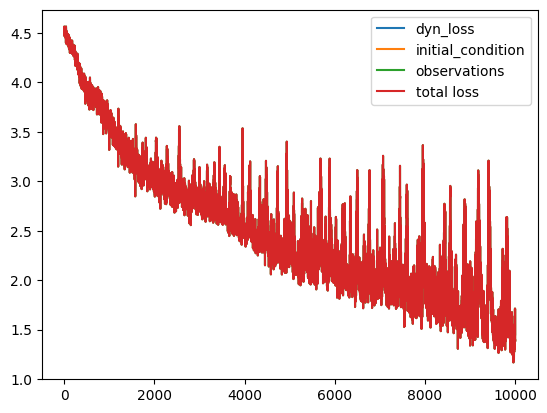

In [20]:
# Vizualizing the trained models results, metrics etc
for loss_name, loss_values in loss_by_term_dict.items():
    #     if loss_name == "dyn_loss":
    plt.plot(jnp.log10(loss_values), label=loss_name)
plt.plot(jnp.log10(total_loss_list), label="total loss")
plt.legend()
plt.show();

In [21]:
# And then we reintroduce the dynamic loss and ponderate each dimensions of the DynamicLoss
alpha = 1
loss_weights = jinns.loss.LossWeightsODE(
    dyn_loss=1,
    observations=1e-2,
)
sbinn = SBINN(
    Tmax=Tmax,
    #vectorial_dyn_loss_ponderation=jnp.array(
     #   [alpha, alpha, alpha * 1e-2, alpha, alpha, alpha]
    #),
)

loss = jinns.loss.LossODE(
    u=u,
    loss_weights=loss_weights,
    dynamic_loss=sbinn,
    initial_condition=None,
    params=init_params,
    obs_slice=jnp.s_[2:3],
)

In [22]:
n_iter = int(30000)

In [23]:
# Optimizer
import optax

tx = optax.adam(learning_rate=1e-3)
key, subkey = random.split(key)
params, total_loss_list, loss_by_term_dict, train_data, loss, opt_state, _, _, _ = (
    jinns.solve(
        n_iter=n_iter,
        init_params=params,
        data=train_data,
        loss=loss,
        obs_data=obs_data,
        optimizer=tx,
        opt_state=opt_state,
    )
)



Compilation took
 1.6234095096588135 

[train] Iteration 0: loss value = 155052.953125
[train] Iteration 1000: loss value = 13174.06640625
[train] Iteration 2000: loss value = 4589.52197265625
[train] Iteration 3000: loss value = 3592.0419921875
[train] Iteration 4000: loss value = 3321.78369140625
[train] Iteration 5000: loss value = 4048.53076171875
[train] Iteration 6000: loss value = 2578.900390625
[train] Iteration 7000: loss value = 1424.8836669921875
[train] Iteration 8000: loss value = 1226.24755859375
[train] Iteration 9000: loss value = 1108.341064453125
[train] Iteration 10000: loss value = 735.867919921875
[train] Iteration 11000: loss value = 654.1492309570312
[train] Iteration 12000: loss value = 948.285400390625
[train] Iteration 13000: loss value = 990.2990112304688
[train] Iteration 14000: loss value = 926.6621704101562
[train] Iteration 15000: loss value = 985.3521728515625
[train] Iteration 16000: loss value = 603.98583984375
[train] Iteration 17000: loss value = 83

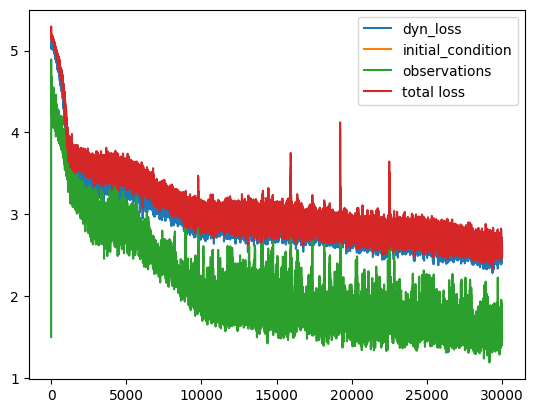

In [24]:
for loss_name, loss_values in loss_by_term_dict.items():
    #     if loss_name == "dyn_loss":
    plt.plot(jnp.log10(loss_values), label=loss_name)
plt.plot(jnp.log10(total_loss_list), label="total loss")
plt.legend()
plt.show();

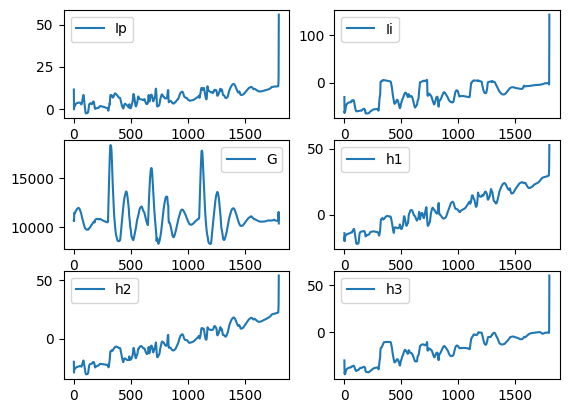

In [29]:
u_est_Ip = vmap(lambda t: u(t, params["nn_params"])[0], (0), 0)
u_est_Ii = vmap(lambda t: u(t, params["nn_params"])[1], (0), 0)
u_est_G = vmap(lambda t: u(t, params["nn_params"])[2], (0), 0)
u_est_h1 = vmap(lambda t: u(t, params["nn_params"])[3], (0), 0)
u_est_h2 = vmap(lambda t: u(t, params["nn_params"])[4], (0), 0)
u_est_h3 = vmap(lambda t: u(t, params["nn_params"])[5], (0), 0)

key, subkey = random.split(key, 2)
val_data = jinns.data.DataGeneratorODE(
    key=subkey,
    nt=nt,
    tmin=tmin,
    tmax=tmax,
    temporal_batch_size=batch_size,
    method=method,
)

fig, axes = plt.subplots(3, 2)
labels = ["Ip", "Ii", "G", "h1", "h2", "h3"]
for i in range(3):
    for j in range(2):
        idx = jnp.ravel_multi_index((i, j), (3, 2))
        u_est_ij = vmap(lambda t: u(t, params)[idx], 0, 0)
        axes[i, j].plot(
            val_data.times.sort(axis=0) * Tmax,
            u_est_ij(val_data.times.sort(axis=0)),
            label=labels[idx],
        )
        axes[i, j].legend()

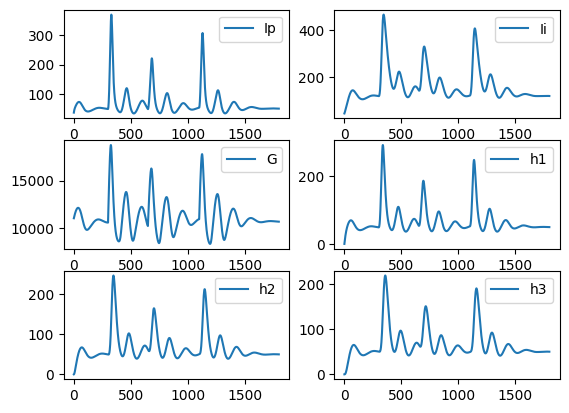

In [30]:
import numpy as np
from scipy.integrate import odeint


def glucose_insulin_model(
    t,
    meal_t,
    meal_q,
    Vp=3,
    Vi=11,
    Vg=10,
    E=0.2,
    tp=6,
    ti=100,
    td=12,
    k=1 / 120,
    Rm=209,
    a1=6.6,
    C1=300,
    C2=144,
    C3=100,
    C4=80,
    C5=26,
    Ub=72,
    U0=4,
    Um=90,
    Rg=180,
    alpha=7.5,
    beta=1.772,
):
    def func(y, t):
        f1 = Rm / (1 + np.exp(-y[2] / Vg / C1 + a1))
        f2 = Ub * (1 - np.exp(-y[2] / Vg / C2))
        kappa = (1 / Vi + 1 / E / ti) / C4
        f3 = (U0 + Um / (1 + (kappa * y[1]) ** (-beta))) / Vg / C3
        f4 = Rg / (1 + np.exp(alpha * (y[5] / Vp / C5 - 1)))
        IG = np.sum(
            meal_q
            * k
            * np.exp(Tmax * k * (meal_t - t))
            * np.heaviside(Tmax * (t - meal_t), 0.5)
        )
        tmp = E * (y[0] / Vp - y[1] / Vi)
        return [
            Tmax * (f1 - tmp - y[0] / tp),
            Tmax * (tmp - y[1] / ti),
            Tmax * (f4 + IG - f2 - f3 * y[2]),
            Tmax * ((y[0] - y[3]) / td),
            Tmax * ((y[3] - y[4]) / td),
            Tmax * ((y[4] - y[5]) / td),
        ]

    Vp0, Vi0, Vg0 = 3, 11, 10
    y0 = [12 * Vp0, 4 * Vi0, 110 * Vg0**2, 0, 0, 0]
    return odeint(func, y0, t)


meal_t = np.array([300, 650, 1100, 2000]) / Tmax
meal_q = np.array([60e3, 40e3, 50e3, 100e3])
t = np.arange(0, 1800, 1)[:, None] / Tmax
y = glucose_insulin_model(np.ravel(t), meal_t, meal_q)

fig, axes = plt.subplots(3, 2)
labels = ["Ip", "Ii", "G", "h1", "h2", "h3"]
for i in range(3):
    for j in range(2):
        idx = jnp.ravel_multi_index((i, j), (3, 2))
        axes[i, j].plot(t * Tmax, y[:, idx], label=labels[idx])
        axes[i, j].legend()